In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math as maths
import torch, torch.nn as nn
import pandas as pd
import copy
import xarray as xr

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

attempt = 1

Using GPU


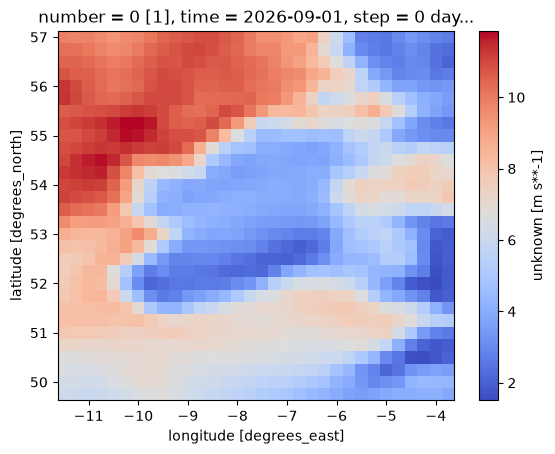

In [49]:
ds = xr.open_dataset(f"project3_data{attempt}.grib", engine="cfgrib")
#print(ds.head)
min_longitude = ds.longitude.values[2]
max_longitude = ds.longitude.values[-1]

cropped_ds = ds.sel(longitude=slice(ds.longitude.values[2], ds.longitude.values[-1]))
#print(cropped_ds.longitude.values)
#print(cropped_ds.head)
data = cropped_ds

#print(data.v10[0])
test_v = data.v10[0]
test_u = data.u10[0]
test_plot = np.sqrt(test_v**2 + test_u**2)

test_plot.plot(cmap = 'coolwarm')

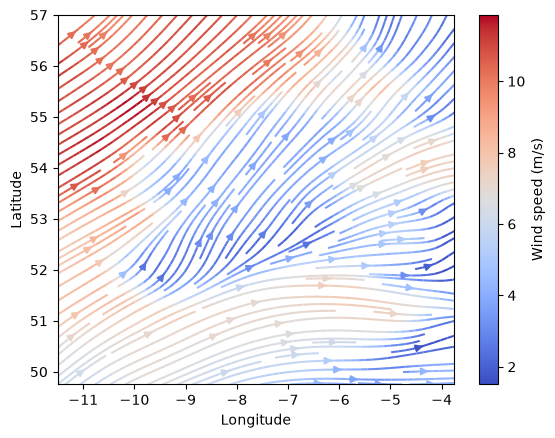

In [ ]:
x = data.longitude.values
y = data.latitude.values[::-1]

xx, yy = np.meshgrid(x, y)
u = data.u10[0][:][::-1]
v = data.v10[0][:][::-1]

#print(xx.shape, yy.shape, u.shape, v.shape)



u_array = np.asarray(u, dtype=float)
v_array = np.asarray(v, dtype=float)
speed = np.hypot(u_array, v_array)

plt.streamplot(
    xx,
    yy,
    u_array,
    v_array,
    color=speed,
    cmap="coolwarm",
    density=1.8
)

plt.colorbar(label="Wind speed (m/s)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Wind Speed and Direction")
plt.show()

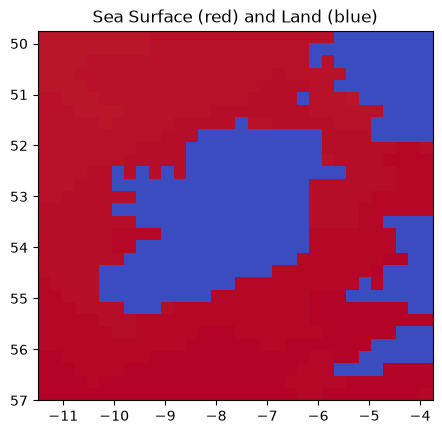

In [48]:
sea_temp = xr.open_dataset(f"sea_temp.grib", engine="cfgrib")
sea_temp_cropped = sea_temp.sel(longitude=slice(min_longitude, max_longitude))
#print(sea_temp_cropped.head)
sst = np.nan_to_num(np.asarray(sea_temp_cropped.sst[:].values), nan = 0.0)
plt.imshow(sst, cmap = 'coolwarm', extent=[min_longitude, max_longitude, data.latitude.values[0], data.latitude.values[-1]])
plt.title("Sea Surface (red) and Land (blue)")
plt.show()



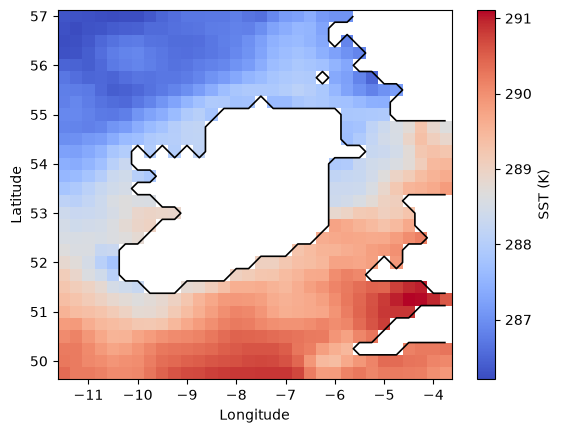

In [44]:
# Land mask: SST is NaN over land (0 after nan_to_num)
sst_lon = sea_temp_cropped.longitude.values
sst_lat = sea_temp_cropped.latitude.values
land_mask = np.isnan(sea_temp_cropped.sst.values).astype(float)

def plot_coastline(ax=None, color="black", linewidth=1.2):
    """Draw the land/sea boundary (0.5 contour of the land mask) on ax."""
    if ax is None:
        ax = plt.gca()
    ax.contour(sst_lon, sst_lat, land_mask, levels=[0.5], colors=color, linewidths=linewidth)

fig, ax = plt.subplots()
sst_plot = ax.pcolormesh(sst_lon, sst_lat, np.where(land_mask == 1, np.nan, sst), cmap="coolwarm", shading="nearest")
plot_coastline(ax)
fig.colorbar(sst_plot, label="SST (K)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
plt.show()

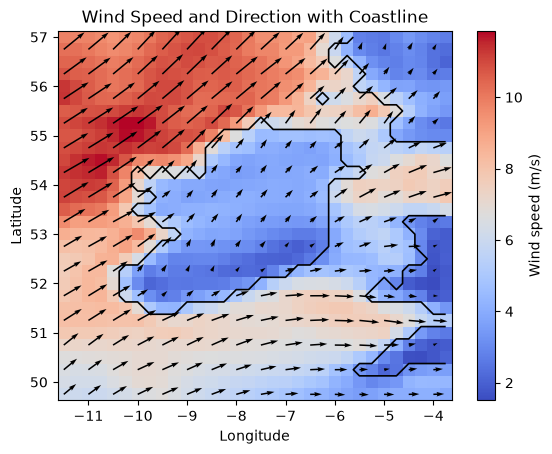

In [61]:
fig, ax = plt.subplots()
plot_coastline(ax)
x = data.longitude.values
y = data.latitude.values[::-1]
xx, yy = np.meshgrid(x, y)
wind_speed = np.sqrt(u_array**2 + v_array**2)
wind_plot = ax.pcolormesh(xx, yy, wind_speed, cmap="coolwarm", shading="nearest")

step = 2

ax.quiver(xx[::step, ::step], yy[::step, ::step], u_array[::step, ::step],
           v_array[::step, ::step], color="black", scale=150)
fig.colorbar(wind_plot, label="Wind speed (m/s)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
plt.title("Wind Speed and Direction with Coastline")
plt.show()
